In [388]:
import math, copy
import numpy as np
import pandas as pd
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [300]:
df = pd.read_csv(r"D:\Programming\Data Science\Data\car data.csv")

In [301]:
print(df)

    Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0       ritz  2014           3.35           5.59       27000    Petrol   
1        sx4  2013           4.75           9.54       43000    Diesel   
2       ciaz  2017           7.25           9.85        6900    Petrol   
3    wagon r  2011           2.85           4.15        5200    Petrol   
4      swift  2014           4.60           6.87       42450    Diesel   
..       ...   ...            ...            ...         ...       ...   
296     city  2016           9.50          11.60       33988    Diesel   
297     brio  2015           4.00           5.90       60000    Petrol   
298     city  2009           3.35          11.00       87934    Petrol   
299     city  2017          11.50          12.50        9000    Diesel   
300     brio  2016           5.30           5.90        5464    Petrol   

    Seller_Type Transmission  Owner  
0        Dealer       Manual      0  
1        Dealer       Manual      0

In [302]:
print(df.head())

  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  


In [303]:
df.shape

(301, 9)

In [304]:
df.index

RangeIndex(start=0, stop=301, step=1)

In [305]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')

In [306]:
df.dtypes

Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
dtype: object

In [307]:
# .unique applicable only on a particular column
df['Car_Name'].unique 

<bound method Series.unique of 0         ritz
1          sx4
2         ciaz
3      wagon r
4        swift
        ...   
296       city
297       brio
298       city
299       city
300       brio
Name: Car_Name, Length: 301, dtype: object>

In [308]:
df.nunique() 

Car_Name          98
Year              16
Selling_Price    156
Present_Price    147
Kms_Driven       206
Fuel_Type          3
Seller_Type        2
Transmission       2
Owner              3
dtype: int64

In [309]:
df.count()

Car_Name         301
Year             301
Selling_Price    301
Present_Price    301
Kms_Driven       301
Fuel_Type        301
Seller_Type      301
Transmission     301
Owner            301
dtype: int64

In [310]:
# applicable only on single column
df['Car_Name'].value_counts()

Car_Name
city                        26
corolla altis               16
verna                       14
fortuner                    11
brio                        10
                            ..
Honda CB Trigger             1
Yamaha FZ S                  1
Bajaj Pulsar 135 LS          1
Activa 4g                    1
Bajaj Avenger Street 220     1
Name: count, Length: 98, dtype: int64

In [311]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None


In [312]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
296    False
297    False
298    False
299    False
300    False
Length: 301, dtype: bool

In [313]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [314]:
df.describe(include='number')

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [315]:
df.describe(include='object')

,Car_Name,Fuel_Type,Seller_Type,Transmission
count,301,301,301,301
unique,98,3,2,2
top,city,Petrol,Dealer,Manual
freq,26,239,195,261


In [316]:
df.describe(include='all')

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
count,301,301.000000,301.000000,301.000000,301.000000,301,301,301,301.000000
unique,98,NaN,NaN,NaN,NaN,3,2,2,NaN
top,city,NaN,NaN,NaN,NaN,Petrol,Dealer,Manual,NaN
freq,26,NaN,NaN,NaN,NaN,239,195,261,NaN
mean,NaN,2013.627907,4.661296,7.628472,36947.205980,NaN,NaN,NaN,0.043189
std,NaN,2.891554,5.082812,8.644115,38886.883882,NaN,NaN,NaN,0.247915
min,NaN,2003.000000,0.100000,0.320000,500.000000,NaN,NaN,NaN,0.000000
25%,NaN,2012.000000,0.900000,1.200000,15000.000000,NaN,NaN,NaN,0.000000
50%,NaN,2014.000000,3.600000,6.400000,32000.000000,NaN,NaN,NaN,0.000000
75%,NaN,2016.000000,6.000000,9.900000,48767.000000,NaN,NaN,NaN,0.000000


In [317]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

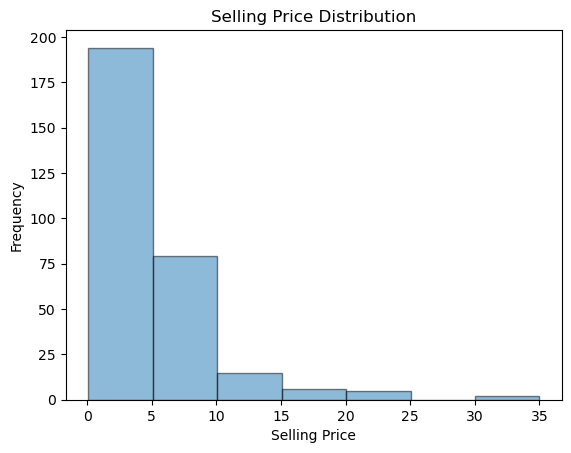

In [318]:
plt.hist(df['Selling_Price'], edgecolor='black', alpha=0.5, bins=7)
plt.title('Selling Price Distribution')
plt.xlabel('Selling Price')
plt.ylabel('Frequency')
plt.show()

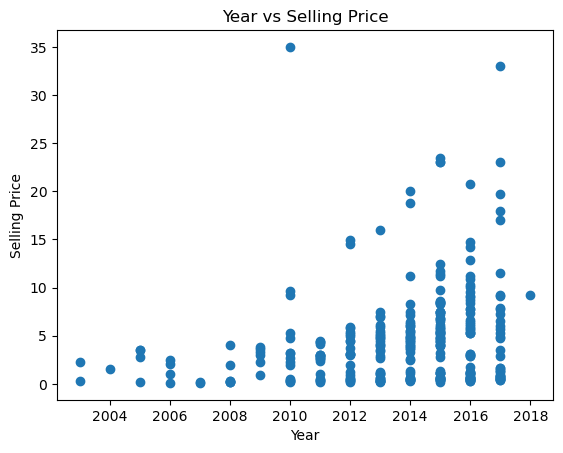

In [319]:
plt.scatter(df['Year'], df['Selling_Price'], marker='o')
plt.title('Year vs Selling Price')
plt.xlabel('Year')
plt.ylabel('Selling Price')
plt.show()

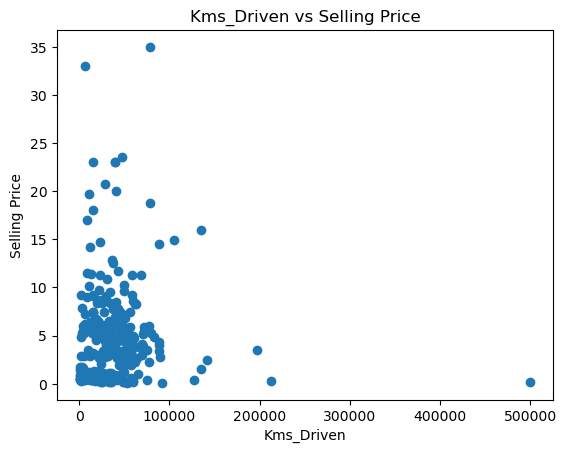

In [320]:
plt.scatter(df['Kms_Driven'], df['Selling_Price'], marker='o')
#plt.xlim(0, 100000)
plt.title('Kms_Driven vs Selling Price')
plt.xlabel('Kms_Driven')
plt.ylabel('Selling Price')
plt.show()

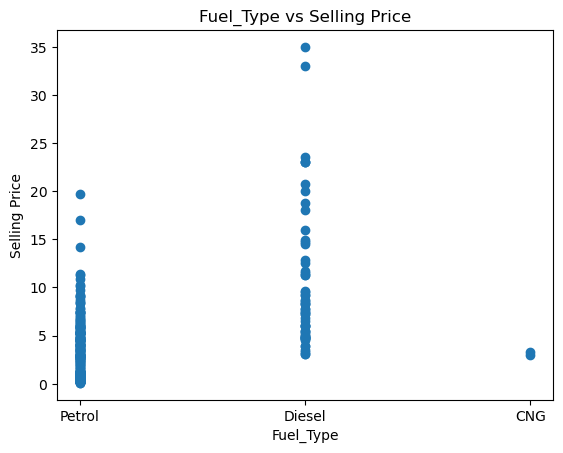

In [321]:
plt.scatter(df['Fuel_Type'], df['Selling_Price'], marker='o')
plt.title('Fuel_Type vs Selling Price')
plt.xlabel('Fuel_Type')
plt.ylabel('Selling Price')
plt.show()

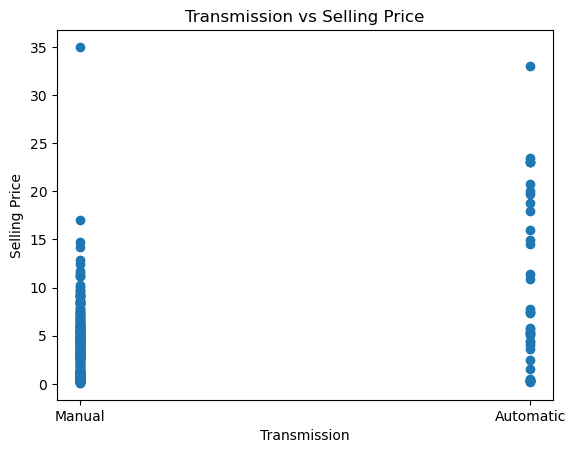

In [322]:
plt.scatter(df['Transmission'], df['Selling_Price'], marker='o')
plt.title('Transmission vs Selling Price')
plt.xlabel('Transmission')
plt.ylabel('Selling Price')
plt.show()

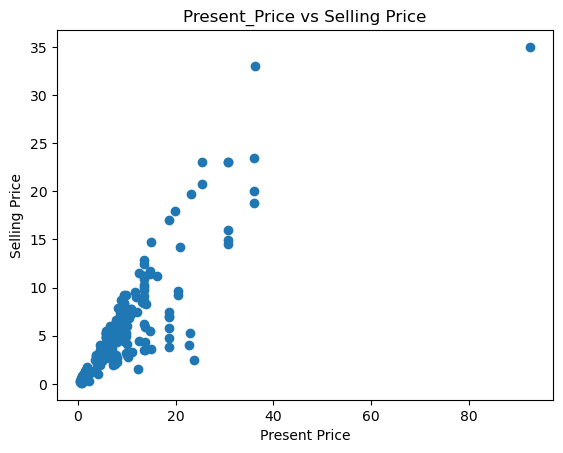

In [323]:
plt.scatter(df['Present_Price'], df['Selling_Price'], marker='o')
#plt.xlim(0, 20)
plt.title('Present_Price vs Selling Price')
plt.xlabel('Present Price')
plt.ylabel('Selling Price')
plt.show()

In [324]:
current_year = datetime.now().year
# Calculate age
df['Age'] = current_year - df['Year']

print(df)


    Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0       ritz  2014           3.35           5.59       27000    Petrol   
1        sx4  2013           4.75           9.54       43000    Diesel   
2       ciaz  2017           7.25           9.85        6900    Petrol   
3    wagon r  2011           2.85           4.15        5200    Petrol   
4      swift  2014           4.60           6.87       42450    Diesel   
..       ...   ...            ...            ...         ...       ...   
296     city  2016           9.50          11.60       33988    Diesel   
297     brio  2015           4.00           5.90       60000    Petrol   
298     city  2009           3.35          11.00       87934    Petrol   
299     city  2017          11.50          12.50        9000    Diesel   
300     brio  2016           5.30           5.90        5464    Petrol   

    Seller_Type Transmission  Owner  Age  
0        Dealer       Manual      0   11  
1        Dealer       Man

In [325]:
columns_to_drop = ['Car_Name', 'Year', 'Owner', 'Seller_Type']
New_df = df.drop(columns_to_drop, axis = 1, inplace=False)
print(New_df)

     Selling_Price  Present_Price  Kms_Driven Fuel_Type Transmission  Age
0             3.35           5.59       27000    Petrol       Manual   11
1             4.75           9.54       43000    Diesel       Manual   12
2             7.25           9.85        6900    Petrol       Manual    8
3             2.85           4.15        5200    Petrol       Manual   14
4             4.60           6.87       42450    Diesel       Manual   11
..             ...            ...         ...       ...          ...  ...
296           9.50          11.60       33988    Diesel       Manual    9
297           4.00           5.90       60000    Petrol       Manual   10
298           3.35          11.00       87934    Petrol       Manual   16
299          11.50          12.50        9000    Diesel       Manual    8
300           5.30           5.90        5464    Petrol       Manual    9

[301 rows x 6 columns]


In [326]:
New_df.shape

(301, 6)

In [327]:
for index, column in enumerate(New_df.columns):
    print(f"Index: {index}, Column: {column}")

Index: 0, Column: Selling_Price
Index: 1, Column: Present_Price
Index: 2, Column: Kms_Driven
Index: 3, Column: Fuel_Type
Index: 4, Column: Transmission
Index: 5, Column: Age


In [328]:
print(New_df['Age'])

0      11
1      12
2       8
3      14
4      11
       ..
296     9
297    10
298    16
299     8
300     9
Name: Age, Length: 301, dtype: int64


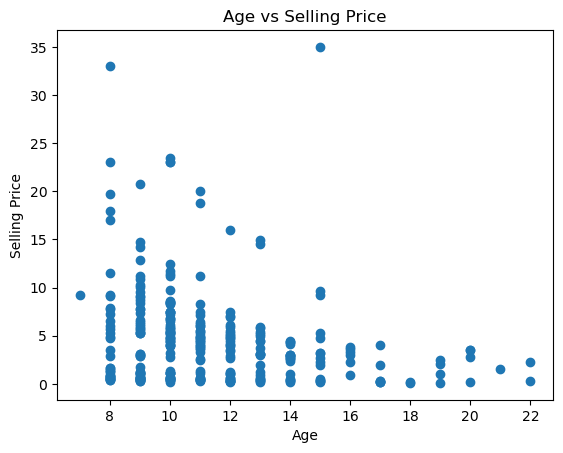

In [329]:
plt.scatter(df['Age'], df['Selling_Price'], marker='o')
plt.title('Age vs Selling Price')
plt.xlabel('Age')
plt.ylabel('Selling Price')
plt.show()

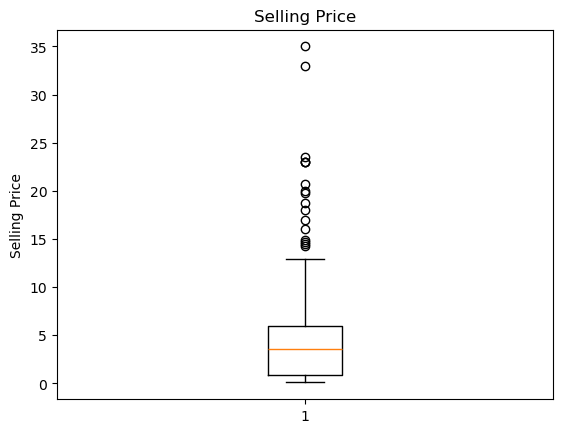

In [330]:
# Create box plot
plt.boxplot(New_df['Selling_Price'])

# Add labels
plt.title("Selling Price")
plt.ylabel("Selling Price")

# Show the plot
plt.show()


In [331]:
New_df[New_df['Selling_Price']>12]

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Transmission,Age
50,14.90,30.61,104707,Diesel,Automatic,13
51,23.00,30.61,40000,Diesel,Automatic,10
52,18.00,19.77,15000,Diesel,Automatic,8
53,16.00,30.61,135000,Diesel,Automatic,12
59,19.99,35.96,41000,Diesel,Automatic,11
62,18.75,35.96,78000,Diesel,Automatic,11
63,23.50,35.96,47000,Diesel,Automatic,10
64,33.00,36.23,6000,Diesel,Automatic,8
66,19.75,23.15,11000,Petrol,Automatic,8
69,14.25,20.91,12000,Petrol,Manual,9


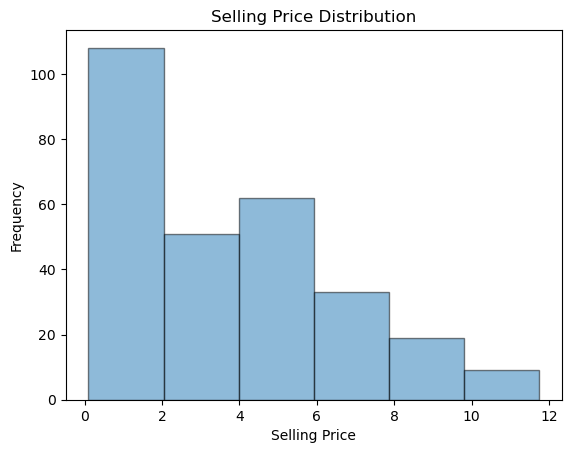

In [332]:
New_df = New_df.drop(New_df[New_df['Selling_Price'] > 12].index)

plt.hist(New_df['Selling_Price'], edgecolor='black', alpha=0.5, bins=6)
plt.title('Selling Price Distribution')
plt.xlabel('Selling Price')
plt.ylabel('Frequency')
plt.show()

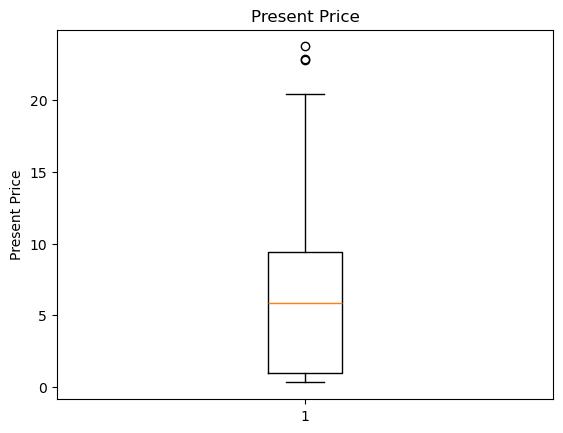

In [333]:
# Create box plot
plt.boxplot(New_df['Present_Price'])

# Add labels
plt.title("Present Price")
plt.ylabel("Present Price")

# Show the plot
plt.show()


In [334]:
New_df[New_df['Present_Price']>22.8]

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Transmission,Age
78,5.25,22.83,80000,Petrol,Automatic,15
85,2.50,23.73,142000,Petrol,Automatic,19


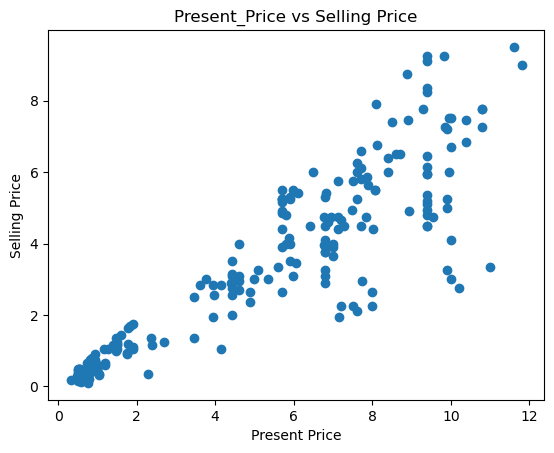

In [335]:
New_df = New_df.drop(New_df[New_df['Present_Price'] > 12].index)
plt.scatter(New_df['Present_Price'], New_df['Selling_Price'], marker='o')
#plt.xlim(0, 20)
plt.title('Present_Price vs Selling Price')
plt.xlabel('Present Price')
plt.ylabel('Selling Price')
plt.show()

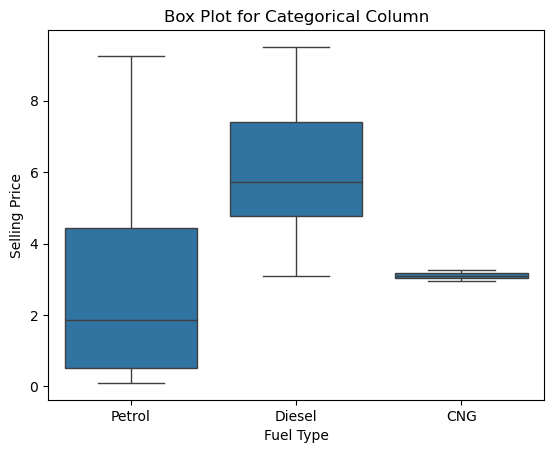

In [336]:
# Create a box plot for the categorical column 'Category'
sns.boxplot(x=New_df['Fuel_Type'], y=New_df['Selling_Price'], data=New_df)

# Add labels and title
plt.title("Box Plot for Categorical Column")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")

# Show the plot
plt.show()

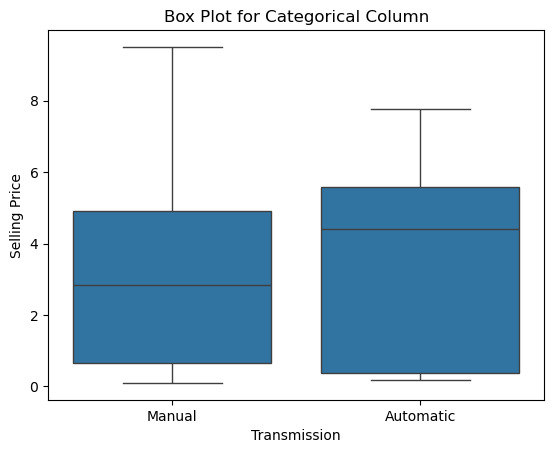

In [337]:
# Create a box plot for the categorical column 'Category'
sns.boxplot(x=New_df['Transmission'], y=New_df['Selling_Price'], data=New_df)

# Add labels and title
plt.title("Box Plot for Categorical Column")
plt.xlabel("Transmission")
plt.ylabel("Selling Price")

# Show the plot
plt.show()

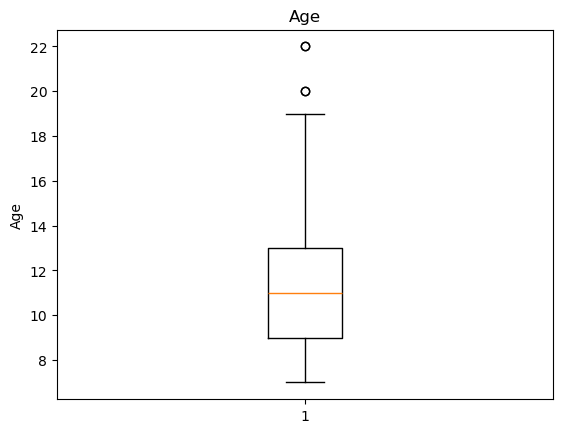

In [338]:
# Create box plot
plt.boxplot(New_df['Age'])

# Add labels
plt.title("Age")
plt.ylabel("Age")

# Show the plot
plt.show()


In [339]:
New_df[New_df['Age']>19]

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Transmission,Age
37,0.35,2.28,127000,Petrol,Manual,22
39,2.25,7.98,62000,Petrol,Manual,22
54,2.75,10.21,90000,Petrol,Manual,20
189,0.20,0.57,55000,Petrol,Manual,20


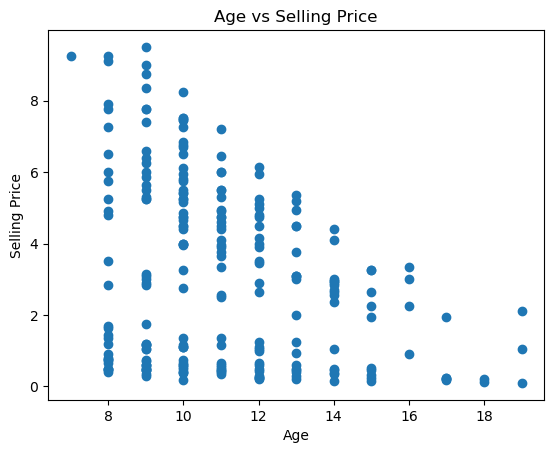

In [340]:
New_df = New_df.drop(New_df[New_df['Age'] > 19].index)
plt.scatter(New_df['Age'], New_df['Selling_Price'], marker='o')
plt.title('Age vs Selling Price')
plt.xlabel('Age')
plt.ylabel('Selling Price')
plt.show()

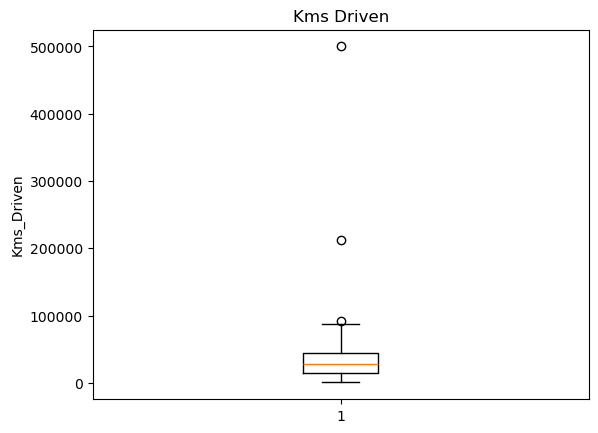

In [341]:
# Create box plot
plt.boxplot(New_df['Kms_Driven'])

# Add labels
plt.title("Kms Driven")
plt.ylabel("Kms_Driven")

# Show the plot
plt.show()

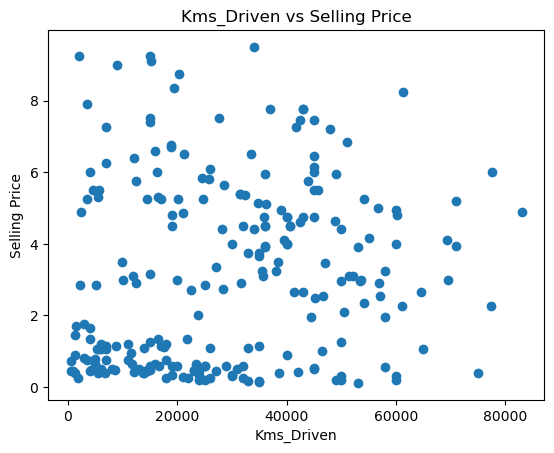

In [342]:
New_df = New_df.drop(New_df[New_df['Kms_Driven'] > 85000].index)
plt.scatter(New_df['Kms_Driven'], New_df['Selling_Price'], marker='o')
plt.title('Kms_Driven vs Selling Price')
plt.xlabel('Kms_Driven')
plt.ylabel('Selling Price')
plt.show()

In [343]:
New_df.reset_index(drop=True, inplace=True)

In [344]:
print(New_df)

     Selling_Price  Present_Price  Kms_Driven Fuel_Type Transmission  Age
0             3.35           5.59       27000    Petrol       Manual   11
1             4.75           9.54       43000    Diesel       Manual   12
2             7.25           9.85        6900    Petrol       Manual    8
3             2.85           4.15        5200    Petrol       Manual   14
4             4.60           6.87       42450    Diesel       Manual   11
..             ...            ...         ...       ...          ...  ...
231           3.25           9.90       38000    Petrol       Manual   15
232           3.75           6.80       33019    Petrol       Manual   11
233           9.50          11.60       33988    Diesel       Manual    9
234           4.00           5.90       60000    Petrol       Manual   10
235           5.30           5.90        5464    Petrol       Manual    9

[236 rows x 6 columns]


In [345]:
# Initialize the LabelEncoder
le = LabelEncoder()

# Fit and transform the 'Category' column
New_df['Fuel_Type_encoded'] = le.fit_transform(New_df['Fuel_Type'])

In [346]:
print(New_df)

     Selling_Price  Present_Price  Kms_Driven Fuel_Type Transmission  Age  \
0             3.35           5.59       27000    Petrol       Manual   11   
1             4.75           9.54       43000    Diesel       Manual   12   
2             7.25           9.85        6900    Petrol       Manual    8   
3             2.85           4.15        5200    Petrol       Manual   14   
4             4.60           6.87       42450    Diesel       Manual   11   
..             ...            ...         ...       ...          ...  ...   
231           3.25           9.90       38000    Petrol       Manual   15   
232           3.75           6.80       33019    Petrol       Manual   11   
233           9.50          11.60       33988    Diesel       Manual    9   
234           4.00           5.90       60000    Petrol       Manual   10   
235           5.30           5.90        5464    Petrol       Manual    9   

     Fuel_Type_encoded  
0                    2  
1                    1  


In [347]:
# Initialize the LabelEncoder
le = LabelEncoder()

# Fit and transform the 'Category' column
New_df['Transmission_encoded'] = le.fit_transform(New_df['Transmission'])

In [348]:
print(New_df)

     Selling_Price  Present_Price  Kms_Driven Fuel_Type Transmission  Age  \
0             3.35           5.59       27000    Petrol       Manual   11   
1             4.75           9.54       43000    Diesel       Manual   12   
2             7.25           9.85        6900    Petrol       Manual    8   
3             2.85           4.15        5200    Petrol       Manual   14   
4             4.60           6.87       42450    Diesel       Manual   11   
..             ...            ...         ...       ...          ...  ...   
231           3.25           9.90       38000    Petrol       Manual   15   
232           3.75           6.80       33019    Petrol       Manual   11   
233           9.50          11.60       33988    Diesel       Manual    9   
234           4.00           5.90       60000    Petrol       Manual   10   
235           5.30           5.90        5464    Petrol       Manual    9   

     Fuel_Type_encoded  Transmission_encoded  
0                    2      

In [349]:
New_df.shape

(236, 8)

In [350]:
columns_to_drop = ['Fuel_Type', 'Transmission']
New_df = New_df.drop(columns_to_drop, axis = 1, inplace=False)
print(New_df)

     Selling_Price  Present_Price  Kms_Driven  Age  Fuel_Type_encoded  \
0             3.35           5.59       27000   11                  2   
1             4.75           9.54       43000   12                  1   
2             7.25           9.85        6900    8                  2   
3             2.85           4.15        5200   14                  2   
4             4.60           6.87       42450   11                  1   
..             ...            ...         ...  ...                ...   
231           3.25           9.90       38000   15                  2   
232           3.75           6.80       33019   11                  2   
233           9.50          11.60       33988    9                  1   
234           4.00           5.90       60000   10                  2   
235           5.30           5.90        5464    9                  2   

     Transmission_encoded  
0                       1  
1                       1  
2                       1  
3          

In [351]:
New_df.shape

(236, 6)

In [400]:
x = New_df.drop('Selling_Price',axis=1)
y = New_df['Selling_Price']

# Split data into training and testing sets (80% train, 20% test)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.15, random_state=42)

# Display the shape of the splits
print(f"Training data shape: {x_train.shape}")
print(f"Testing data shape: {x_test.shape}")

Training data shape: (200, 5)
Testing data shape: (36, 5)


In [401]:
print(x_train)

     Present_Price  Kms_Driven  Age  Fuel_Type_encoded  Transmission_encoded
165           6.79       31604   14                  2                     1
16           10.79       41678   10                  1                     1
211           7.00       35000   11                  2                     1
178           5.70       24678   10                  2                     1
162           8.10        3435    8                  2                     1
..             ...         ...  ...                ...                   ...
106           0.94       45000   15                  2                     1
14            7.21       77427   16                  2                     1
92            0.81       11800    8                  2                     1
179           4.43       57000   14                  2                     1
102           0.99       25000   11                  2                     1

[200 rows x 5 columns]


In [402]:
print(y_train)

165    2.90
16     7.25
211    3.65
178    5.25
162    7.90
       ... 
106    0.52
14     2.25
92     0.65
179    2.55
102    0.60
Name: Selling_Price, Length: 200, dtype: float64


In [403]:
#initialize
scaler = StandardScaler()

# Fit and transform the training data
x_norm = scaler.fit_transform(x_train)

# Calculate and print the peak-to-peak range for each column in raw X_train
raw_peak_to_peak = np.ptp(x_train, axis=0)
print(f"Peak to Peak range by column in Raw X: {raw_peak_to_peak}")

# Calculate and print the peak-to-peak range for each column in normalized X_norm
normalized_peak_to_peak = np.ptp(x_norm, axis=0)
print(f"Peak to Peak range by column in Normalized X: {normalized_peak_to_peak}")


Peak to Peak range by column in Raw X: Present_Price              11.48
Kms_Driven              82500.00
Age                        12.00
Fuel_Type_encoded           2.00
Transmission_encoded        1.00
dtype: float64
Peak to Peak range by column in Normalized X: [3.29670734 4.25799489 5.09657534 5.46409338 3.6860489 ]


In [404]:
print(x_norm)

[[ 6.01281513e-01  1.35481398e-01  1.28900885e+00  3.96146770e-01
   2.94883912e-01]
 [ 1.74996003e+00  6.55421283e-01 -4.09849600e-01 -2.33589992e+00
   2.94883912e-01]
 [ 6.61587135e-01  3.10755951e-01  1.48650114e-02  3.96146770e-01
   2.94883912e-01]
 [ 2.88266617e-01 -2.21983725e-01 -4.09849600e-01  3.96146770e-01
   2.94883912e-01]
 [ 9.77473728e-01 -1.31837870e+00 -1.25927882e+00  3.96146770e-01
   2.94883912e-01]
 [ 2.88266617e-01  3.00278703e-01 -4.09849600e-01  3.96146770e-01
  -3.39116499e+00]
 [-1.19065697e+00 -1.44405407e+00 -8.34564211e-01  3.96146770e-01
   2.94883912e-01]
 [-8.37438330e-01 -1.28921789e+00 -1.25927882e+00  3.96146770e-01
   2.94883912e-01]
 [ 1.49437906e+00  1.43078925e+00  4.39579623e-01  3.96146770e-01
   2.94883912e-01]
 [ 1.49437906e+00  4.65592129e-01  1.71372346e+00  3.96146770e-01
   2.94883912e-01]
 [-8.46053419e-01 -9.02127443e-01  8.64294234e-01  3.96146770e-01
   2.94883912e-01]
 [-1.20214376e+00 -1.28921789e+00 -1.25927882e+00  3.96146770e-01

In [405]:
# Initialize the SGDRegressor with a maximum of 1000 iterations
sgdr = SGDRegressor(max_iter=1000)

# Fit the model on the normalized features (X_norm) and target values (y_train)
sgdr.fit(x_norm, y_train)

# Print the model details
print(sgdr)

print(f"number of iterations completed: {sgdr.n_iter_}, number of weight updates: {sgdr.t_}")

SGDRegressor()
number of iterations completed: 21, number of weight updates: 4201.0


In [406]:
# Extract model parameters: intercept (b) and coefficients (w)
b_norm = sgdr.intercept_
w_norm = sgdr.coef_

# Print the model parameters (intercept and coefficients)
print(f"model parameters:                   w: {w_norm}, b:{b_norm}")


model parameters:                   w: [ 2.32384597 -0.2593166  -0.4904849  -0.1450216  -0.02091379], b:[3.15047323]


In [407]:
# Initialize the model
model = LinearRegression()

# Train the model
model.fit(x_train, y_train)

LinearRegression()

In [408]:
# make a prediction using model
y_pred_model = model.predict(x_test)

In [409]:
print(y_pred_model)

[ 1.61631862  6.22244134  4.12106919  6.29740089  0.68720425  0.60697488
  4.19761578  0.96945069 -1.04622738  7.75114751  5.6601723   5.60584884
  4.67016448  3.57975462  3.21712082 -1.2436449   4.37590022  0.82796672
  5.00064688  2.25565265  6.34007408  3.34358057  0.44653252  3.97703854
  2.76040556  2.87204708  1.46729341  3.55184102  1.54940856  4.14938643
 -0.03569022  1.46564187  5.38591252  0.1492816   0.22935489  5.8094845 ]


In [410]:
# make a prediction using sgdr.predict()
y_pred_sgd = sgdr.predict(x_norm)

# make a prediction using w,b. 
y_pred = np.dot(x_norm, w_norm) + b_norm  

# Check if predictions using both methods match
print(f"prediction using np.dot() and sgdr.predict match: {(y_pred == y_pred_sgd).all()}")

print(f"Prediction on training set:\n{y_pred[:4]}" )
print(f"Target values \n{y_train[:4]}")

prediction using np.dot() and sgdr.predict match: True
Prediction on training set:
[3.81676991 7.58076303 4.5364076  4.01533257]
Target values 
165    2.90
16     7.25
211    3.65
178    5.25
Name: Selling_Price, dtype: float64


In [411]:
print(y_pred)

[ 3.81676991e+00  7.58076303e+00  4.53640760e+00  4.01533257e+00
  6.31788936e+00  3.95699052e+00  1.10376117e+00  2.09275141e+00
  5.97292843e+00  5.59827175e+00  9.30771765e-01  1.32232143e+00
 -1.21894803e+00  5.45385798e+00  4.50718583e+00  8.43254481e+00
  6.19206982e+00  6.30221277e+00  1.79446612e-01  9.53591987e-01
  2.79339965e+00  1.28856226e+00  5.75092248e+00  6.57913972e-01
  4.30519138e+00  3.39961438e+00  1.83551567e-01  8.50410876e+00
  1.79218959e+00  4.65054148e+00  1.31830627e+00  1.85766758e+00
  1.62236112e+00  7.26269326e+00  1.10468304e+00  4.51711193e-01
  6.17186937e-01  8.09516156e+00  3.53351405e+00  3.83443305e-01
 -4.77703742e-01 -3.79523960e-01  9.25409851e-01  5.03288540e-01
  5.59435215e+00  1.10700948e-01  2.24640596e+00  7.05146393e+00
  4.99696980e+00  1.54005350e+00  1.04279072e+00  1.12993523e+00
  5.76869244e-01  3.11957788e+00  4.29063319e+00  4.28549924e+00
  7.02875723e+00  1.17479942e+00  5.49571361e+00  9.76076458e-01
 -3.70127471e-01  1.51466

In [412]:
print(y_pred_sgd)

[ 3.81676991e+00  7.58076303e+00  4.53640760e+00  4.01533257e+00
  6.31788936e+00  3.95699052e+00  1.10376117e+00  2.09275141e+00
  5.97292843e+00  5.59827175e+00  9.30771765e-01  1.32232143e+00
 -1.21894803e+00  5.45385798e+00  4.50718583e+00  8.43254481e+00
  6.19206982e+00  6.30221277e+00  1.79446612e-01  9.53591987e-01
  2.79339965e+00  1.28856226e+00  5.75092248e+00  6.57913972e-01
  4.30519138e+00  3.39961438e+00  1.83551567e-01  8.50410876e+00
  1.79218959e+00  4.65054148e+00  1.31830627e+00  1.85766758e+00
  1.62236112e+00  7.26269326e+00  1.10468304e+00  4.51711193e-01
  6.17186937e-01  8.09516156e+00  3.53351405e+00  3.83443305e-01
 -4.77703742e-01 -3.79523960e-01  9.25409851e-01  5.03288540e-01
  5.59435215e+00  1.10700948e-01  2.24640596e+00  7.05146393e+00
  4.99696980e+00  1.54005350e+00  1.04279072e+00  1.12993523e+00
  5.76869244e-01  3.11957788e+00  4.29063319e+00  4.28549924e+00
  7.02875723e+00  1.17479942e+00  5.49571361e+00  9.76076458e-01
 -3.70127471e-01  1.51466

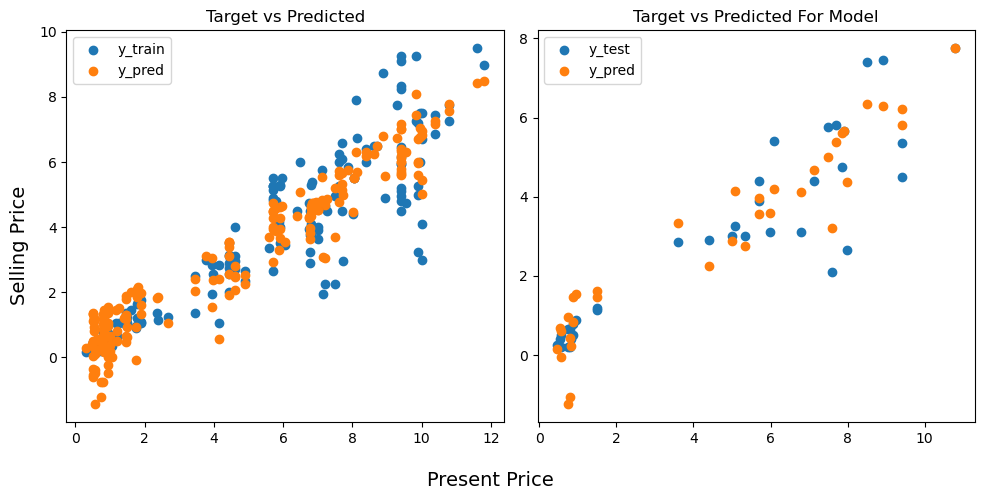

In [462]:
# Create two subplots in one row (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))  # Adjust figsize for better visualization

# Plot on the first subplot (ax1)
ax1.scatter(x_train['Present_Price'], y_train, marker='o', label='y_train')
ax1.scatter(x_train['Present_Price'], y_pred, marker='o', label='y_pred')
ax1.set_title('Target vs Predicted')
ax1.legend(loc='upper left', fontsize=10, ncol=1)  # ncol=2 arranges the legend in two columns
#ax1.set_xlabel('Present Price')
#ax1.set_ylabel('Selling Price')

# Plot on the second subplot (ax2)
ax2.scatter(x_test['Present_Price'], y_test, marker='o', label='y_test')
ax2.scatter(x_test['Present_Price'], y_pred_model, marker='o', label='y_pred')
ax2.set_title('Target vs Predicted For Model')
ax2.legend(loc='upper left', fontsize=10, ncol=1)  # ncol=2 arranges the legend in two columns
#ax2.set_xlabel('Present Price')
#ax2.set_ylabel('Selling Price')

# Add common xlabel and ylabel for the entire figure
fig.supxlabel('Present Price', fontsize=14)
fig.supylabel('Selling Price', fontsize=14)

# Display the plots
plt.tight_layout()  # Adjust layout to avoid overlap
plt.show()


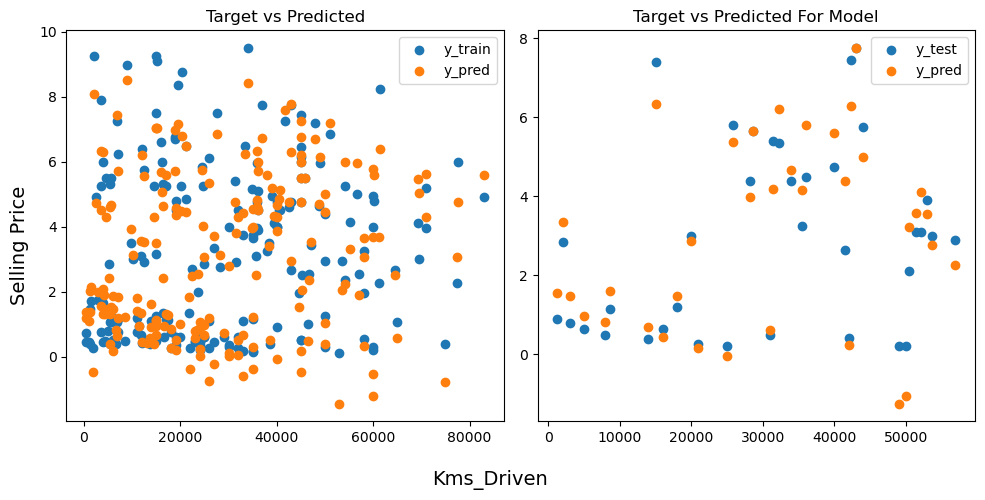

In [460]:
# Create two subplots in one row (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))  # Adjust figsize for better visualization

# Plot on the first subplot (ax1)
ax1.scatter(x_train['Kms_Driven'], y_train, marker='o', label='y_train')
ax1.scatter(x_train['Kms_Driven'], y_pred, marker='o', label='y_pred')
ax1.set_title('Target vs Predicted')
ax1.legend(loc='upper right', fontsize=10, ncol=1)  # ncol=2 arranges the legend in two columns

# Plot on the second subplot (ax2)
ax2.scatter(x_test['Kms_Driven'], y_test, marker='o', label='y_test')
ax2.scatter(x_test['Kms_Driven'], y_pred_model, marker='o', label='y_pred')
ax2.set_title('Target vs Predicted For Model')
ax2.legend(loc='upper right', fontsize=10, ncol=1)  # ncol=2 arranges the legend in two columns

# Add common xlabel and ylabel for the entire figure
fig.supxlabel('Kms_Driven', fontsize=14)
fig.supylabel('Selling Price', fontsize=14)

# Display the plots
plt.tight_layout()  # Adjust layout to avoid overlap
plt.show()


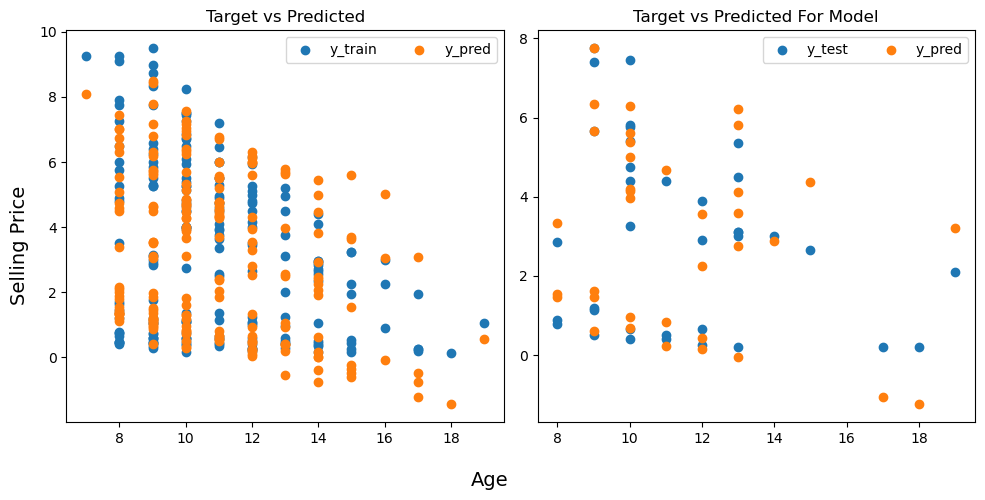

In [456]:
# Create two subplots in one row (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))  # Adjust figsize for better visualization

# Plot on the first subplot (ax1)
ax1.scatter(x_train['Age'], y_train, marker='o', label='y_train')
ax1.scatter(x_train['Age'], y_pred, marker='o', label='y_pred')
ax1.set_title('Target vs Predicted')
ax1.legend(loc='upper right', fontsize=10, ncol=2)  # ncol=2 arranges the legend in two columns

# Plot on the second subplot (ax2)
ax2.scatter(x_test['Age'], y_test, marker='o', label='y_test')
ax2.scatter(x_test['Age'], y_pred_model, marker='o', label='y_pred')
ax2.set_title('Target vs Predicted For Model')
ax2.legend(loc='upper right', fontsize=10, ncol=2)  # ncol=2 arranges the legend in two columns

# Add common xlabel and ylabel for the entire figure
fig.supxlabel('Age', fontsize=14)
fig.supylabel('Selling Price', fontsize=14)

# Display the plots
plt.tight_layout()  # Adjust layout to avoid overlap
plt.show()


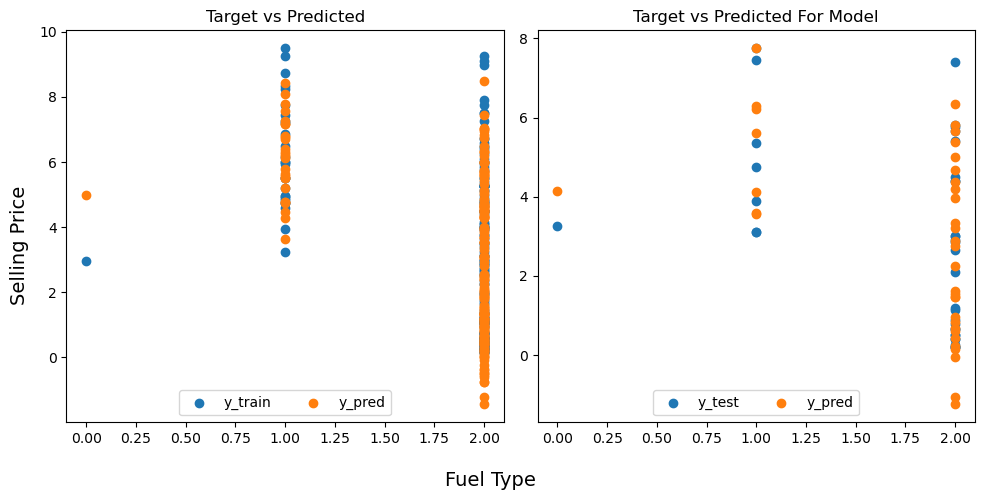

In [453]:
# Create two subplots in one row (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))  # Adjust figsize for better visualization

# Plot on the first subplot (ax1)
ax1.scatter(x_train['Fuel_Type_encoded'], y_train, marker='o', label='y_train')
ax1.scatter(x_train['Fuel_Type_encoded'], y_pred, marker='o', label='y_pred')
ax1.set_title('Target vs Predicted')
ax1.legend(loc='lower center', fontsize=10, ncol=2)  # ncol=2 arranges the legend in two columns

# Plot on the second subplot (ax2)
ax2.scatter(x_test['Fuel_Type_encoded'], y_test, marker='o', label='y_test')
ax2.scatter(x_test['Fuel_Type_encoded'], y_pred_model, marker='o', label='y_pred')
ax2.set_title('Target vs Predicted For Model')
ax2.legend(loc='lower center', fontsize=10, ncol=2)  # ncol=2 arranges the legend in two columns

# Add common xlabel and ylabel for the entire figure
fig.supxlabel('Fuel Type', fontsize=14)
fig.supylabel('Selling Price', fontsize=14)

# Display the plots
plt.tight_layout()  # Adjust layout to avoid overlap
plt.show()


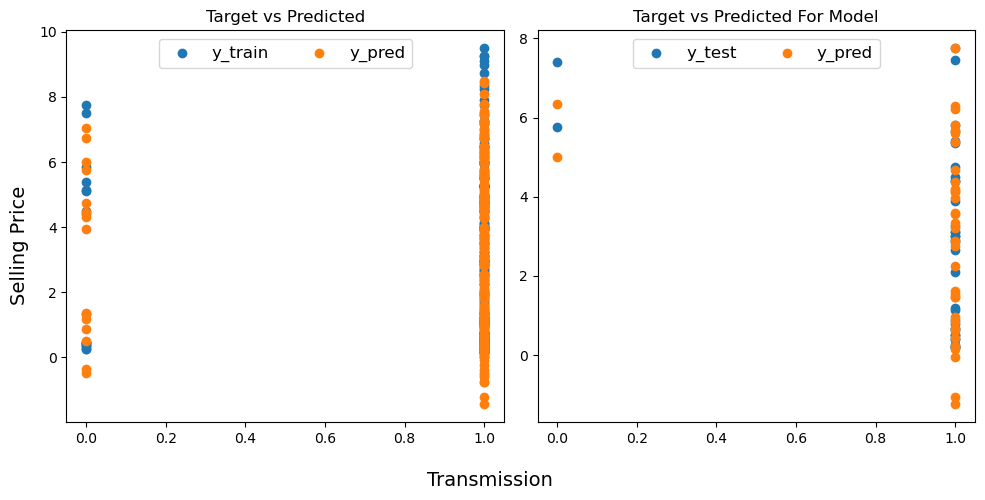

In [450]:
# Create two subplots in one row (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))  # Adjust figsize for better visualization

# Plot on the first subplot (ax1)
ax1.scatter(x_train['Transmission_encoded'], y_train, marker='o', label='y_train')
ax1.scatter(x_train['Transmission_encoded'], y_pred, marker='o', label='y_pred')
ax1.set_title('Target vs Predicted')
ax1.legend(loc='upper center', fontsize=12, ncol=2)  # ncol=2 arranges the legend in two columns

# Plot on the second subplot (ax2)
ax2.scatter(x_test['Transmission_encoded'], y_test, marker='o', label='y_test')
ax2.scatter(x_test['Transmission_encoded'], y_pred_model, marker='o', label='y_pred')
ax2.set_title('Target vs Predicted For Model')
ax2.legend(loc='upper center', fontsize=12, ncol=2)  # ncol=2 arranges the legend in two columns

# Add common xlabel and ylabel for the entire figure
fig.supxlabel('Transmission', fontsize=14)
fig.supylabel('Selling Price', fontsize=14)

# Display the plots
plt.tight_layout()  # Adjust layout to avoid overlap
plt.show()


In [418]:
# Compute R² Score
r2 = r2_score(y_train, y_pred)
print(f"R² Score: {r2}")

r2_model = r2_score(y_test, y_pred_model)
print(f"R² Score: {r2_model}")

R² Score: 0.9181592362956508
R² Score: 0.8922956110000115


In [419]:
# Compute Mean Absolute Error
mae = mean_absolute_error(y_train, y_pred)
print(f"Mean Absolute Error (MAE): {mae}")

mae_model = mean_absolute_error(y_test, y_pred_model)
print(f"Mean Absolute Error (MAE): {mae_model}")

Mean Absolute Error (MAE): 0.5633384087582225
Mean Absolute Error (MAE): 0.6096691193339402


In [420]:
# Compute MSE
mse = mean_squared_error(y_train, y_pred)
print(f"Mean Squared Error (MSE): {mse}")

mse_model = mean_squared_error(y_test, y_pred_model)
print(f"Mean Squared Error (MSE): {mse_model}")

Mean Squared Error (MSE): 0.530588479158479
Mean Squared Error (MSE): 0.5693552101029626


In [421]:
# Compute RMSE
rmse = np.sqrt(mean_squared_error(y_train, y_pred))
print(f"Root Mean Squared Error (RMSE): {rmse}")

rmse_model = np.sqrt(mean_squared_error(y_test, y_pred_model))
print(f"Root Mean Squared Error (RMSE): {rmse_model}")

Root Mean Squared Error (RMSE): 0.7284150459446036
Root Mean Squared Error (RMSE): 0.7545563001545761
